In [1]:
import pulp
import networkx as nx
import matplotlib.pyplot as plt
%load_ext jupyter_black

In [2]:
G = nx.Graph()
G.add_nodes_from(range(1, 26))
pos = {
    1: (0, 8),
    2: (-1, 7),
    3: (1, 7),
    4: (-2, 6),
    5: (0, 6),
    6: (2, 6),
    7: (-3, 5),
    8: (-1, 5),
    9: (1, 5),
    10: (3, 5),
    11: (-4, 4),
    12: (-2, 4),
    13: (0, 4),
    14: (2, 4),
    15: (4, 4),
    16: (-3, 3),
    17: (-1, 3),
    18: (1, 3),
    19: (3, 3),
    20: (-2, 2),
    21: (0, 2),
    22: (2, 2),
    23: (-1, 1),
    24: (1, 1),
    25: (0, 0),
}
diagonal_edges = [
    (1, 2),
    (1, 3),
    (2, 4),
    (2, 5),
    (4, 8),
    (5, 8),
    (6, 9),
    (6, 10),
    (9, 13),
    (9, 14),
    (10, 14),
    (10, 15),
    (11, 16),
    (12, 16),
    (13, 17),
    (13, 18),
    (14, 18),
    (14, 19),
    (15, 19),
    (16, 20),
    (17, 21),
    (18, 21),
    (18, 22),
    (19, 22),
    (20, 23),
    (22, 24),
    (23, 25),
]
horizontal_edges = [(2, 3), (5, 6), (7, 8), (8, 9), (16, 17), (20, 21), (23, 24)]
G.add_edges_from(diagonal_edges)
G.add_edges_from(horizontal_edges)

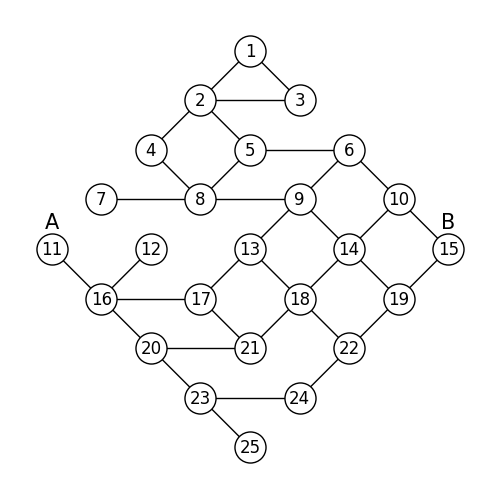

In [3]:
nx.draw(G, pos, node_color="white", edgecolors="black", node_size=500, with_labels=True)
endpoints = {11: "A", 15: "B"}
label_pos = {node: (x, y + 0.55) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(
    G, label_pos, labels=endpoints, font_size=15, font_color="black"
)
plt.gca().set_aspect("equal")
plt.show()

In [4]:
days = list(range(1, G.number_of_nodes() + 1))

In [5]:
# create problem
prob = pulp.LpProblem("jungle", pulp.LpMaximize)

# x[i][t][k]=1 if k on cell i on day t
x = pulp.LpVariable.dicts("x", (G.nodes(), days, ["A", "B"]), cat=pulp.LpBinary)
# y[t]=1 if A and B meet on day t
y = pulp.LpVariable.dicts("y", G.nodes(), cat=pulp.LpBinary)
# z[i][t]=1 if A and B are on cell i on day t
z = pulp.LpVariable.dicts("z", (G.nodes(), days), cat=pulp.LpBinary)

# maximize meeting time to find first meeting point
prob += pulp.lpSum(y)

# one cell per day
for k in ["A", "B"]:
    for t in days:
        prob += pulp.lpSum(x[i][t][k] for i in G.nodes()) == 1

# enforce starting points
prob += x[11][1]["A"] == 1
prob += x[15][1]["B"] == 1

# connexity
for k in ["A", "B"]:
    for i in G.nodes():
        for t in days:
            if t > 1:
                prob += x[i][t][k] <= pulp.lpSum(x[j][t - 1][k] for j in G.neighbors(i))

# define together
for k in ["A", "B"]:
    for i in G.nodes():
        for t in days:
            prob += z[i][t] <= x[i][t][k]

# together implies meeting
for t in days:
    prob += y[t] <= pulp.lpSum(z[i][t] for i in G.nodes())

In [6]:
prob.solve()

1

In [7]:
pulp.LpStatus[prob.status], pulp.value(prob.objective)

('Optimal', 18.0)

In [8]:
first_meeting_day = None
for t in days:
    if pulp.value(y[t]) > 0.9:
        # print("meeting at day",t)
        if not first_meeting_day:
            first_meeting_day = t

# for t in G.nodes():
#    for i in G.nodes():
#        if pulp.value(z[i][t])>0.9:
#            print("meeting at day",t,"on cell",i)

for i in G.nodes():
    G.nodes[i]["value"] = None

for k in ["A", "B"]:
    meet = False
    for t in days:
        for i in G.nodes():
            val = pulp.value(x[i][t][k])
            if val > 0.9 and not meet:
                G.nodes[i]["value"] = k
                if pulp.value(y[t]) > 0.9:
                    G.nodes[i]["value"] = "meeting_point"
                    meet = True
                meeting_point = i
                # print(k,"day",t,"node",i)

A_path = []
for t in G.nodes():
    if t <= first_meeting_day:
        for i in G.nodes():
            if pulp.value(x[i][t]["A"]) > 0.9:
                A_path.append(i)

B_path = []
for t in G.nodes():
    if t <= first_meeting_day:
        for i in G.nodes():
            if pulp.value(x[i][t]["B"]) > 0.9:
                B_path.append(i)

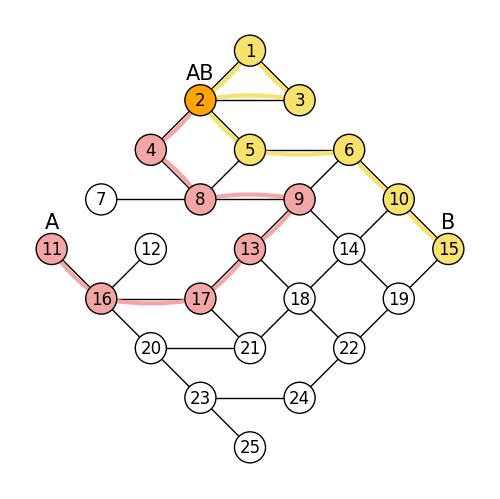

In [9]:
color_map = {
    "A": "#f4a6a6",  # light red
    "B": "#f7e26b",  # yellow
    "meeting_point": "orange",
}
nx.draw(
    G,
    pos,
    node_color=[
        color_map[G.nodes[p]["value"]] if G.nodes[p]["value"] is not None else "white"
        for p in G.nodes()
    ],
    edgecolors="black",
    node_size=500,
    with_labels=True,
)
endpoints[meeting_point] = "AB"
nx.draw_networkx_labels(
    G, label_pos, labels=endpoints, font_size=15, font_color="black"
)


def path_to_edges(path):
    return [(path[i], path[i + 1]) for i in range(len(path) - 1)]


nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_to_edges(A_path),
    edge_color="#f4a6a6",
    width=3,
    arrows=True,
    connectionstyle="arc3,rad=0.1",
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_to_edges(B_path),
    edge_color="#f7e26b",
    width=3,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=-0.1",
)

plt.gca().set_aspect("equal")
plt.show()